<a href="https://colab.research.google.com/github/UlaStats/MSc-project-pipe-failure-prediction/blob/main/Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MSc Project - Modelling

This notebook contains code for MSc project on modelling time-to-failure of water mains. First, feature engineering visually and statistically examines correlations between features and the response attributes. Second, machine learning regression models are trained - XGBoost,

# Import data

In [5]:
# mount Google Drive

from google.colab import drive

drive.mount("/content/drive", force_remount = True)

Mounted at /content/drive


In [6]:
# import data

import pandas as pd

attributes = pd.read_csv("/content/drive/MyDrive/MSc project/attributes.csv", encoding = "latin1")

X_train = pd.read_csv("/content/drive/MyDrive/MSc project/X_train.csv", encoding = "latin1")
X_valid = pd.read_csv("/content/drive/MyDrive/MSc project/X_valid.csv", encoding = "latin1")
X_test = pd.read_csv("/content/drive/MyDrive/MSc project/X_test.csv", encoding = "latin1")


y_train = pd.read_csv("/content/drive/MyDrive/MSc project/y_train.csv", encoding = "latin1")
y_valid = pd.read_csv("/content/drive/MyDrive/MSc project/y_valid.csv", encoding = "latin1")
y_test = pd.read_csv("/content/drive/MyDrive/MSc project/y_test.csv", encoding = "latin1")

In [7]:
# convert categorical columns

X_train['Lining'] = X_train['Lining'].astype("category")
X_train['Surface'] = X_train['Surface'].astype("category")
X_train['Soil'] = X_train['Soil'].astype("category")
X_train['Material'] = X_train['Material'].astype("category")


X_valid['Lining'] = X_valid['Lining'].astype("category")
X_valid['Surface'] = X_valid['Surface'].astype("category")
X_valid['Soil'] = X_valid['Soil'].astype("category")
X_valid['Material'] = X_valid['Material'].astype("category")


X_test['Lining'] = X_test['Lining'].astype("category")
X_test['Surface'] = X_test['Surface'].astype("category")
X_test['Soil'] = X_test['Soil'].astype("category")
X_test['Material'] = X_test['Material'].astype("category")


# Feature Engineering

In this section, features are tested for correlation with the response attribute. This is done using visualisations and statistical tests.

{'whiskers': [<matplotlib.lines.Line2D at 0x7de7dc2bcb30>,
 'caps': [<matplotlib.lines.Line2D at 0x7de7dc9bd8b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7de7dc9bd0a0>],
 'medians': [<matplotlib.lines.Line2D at 0x7de7dc9bdeb0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7de7dc9be150>],
 'means': []}

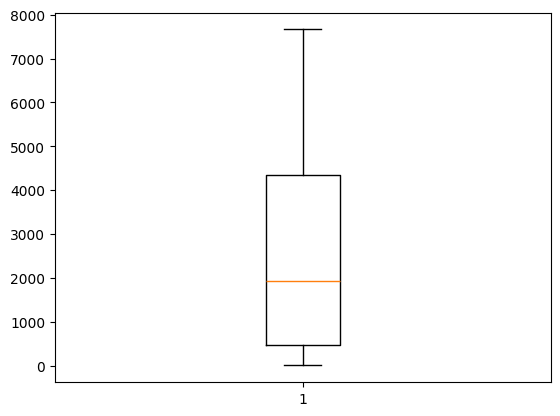

In [ ]:
plt.boxplot(attributes['Time-to-break'])

### Numerical attributes

In this section, correlations are visually examined and statistically tested between numerical attributes.

In [ ]:
# Examine correlations between numerical attributes

sns.pairplot(attributes.drop(columns = ["Asset.ID"]))

##### Length

In [ ]:
# length vs time-to-break

plt.scatter(np.log(attributes['Length']), attributes["Time-to-break"]) # take log of length as highly skewed
plt.xlabel("log[Length (m)]")
plt.ylabel("Time-to-break (days)")

# comment: no strong relationship

In [ ]:
# length vs time-to-break

test = stats.spearmanr(a = attributes['Length'], b = attributes["Time-to-break"])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

##### Diamater

In [ ]:
# diamater vs time to break

plt.scatter(attributes['Diameter'], attributes["Time-to-break"])
plt.xlabel("Diamater (mm)")
plt.ylabel("Time-to-break (days)")

# comment: no obvious relationship

In [ ]:
# diamater vs time-to-break

test = stats.spearmanr(a = attributes['Diameter'], b = attributes["Time-to-break"])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

##### Age

In [ ]:
# time to break vs age

plt.scatter(attributes["Age"], attributes["Time-to-break"])
plt.xlabel("Age")
plt.ylabel("Time-to-break (days)")


# comment: no relationship

In [ ]:
# age vs time-to-break

test = stats.spearmanr(a = attributes['Age'], b = attributes["Time-to-break"])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

##### Previous bursts

In [ ]:
# previous bursts vs time-to-break

plt.scatter(np.log(attributes['Previous bursts'][attributes['Previous bursts'] > 0]), attributes["Time-to-break"][attributes['Previous bursts'] > 0])
plt.xlabel("log[Previous bursts]")
plt.ylabel("Time-to-break (days)")

# comment: no strong relationship

In [ ]:
# age vs time-to-break

test = stats.spearmanr(a = attributes['Previous bursts'][attributes['Previous bursts'] > 0], b = attributes["Time-to-break"][attributes['Previous bursts'] > 0])


print("statistic", test.statistic)
print("p-value", test.pvalue)


# comment: weak negative relationship

### Categorical attributes

##### Material

In [ ]:
# material vs time-to-break

plt.figure(figsize = (12, 5))
sns.boxplot( y = np.log(attributes["Time-to-break"]), x = attributes["Material"]) # adding a constant 10 to avoid infinity at time-to-break = 0
plt.ylabel("log[Time-to-break]")

# comment: some materials such as PE or Steel seem to have slightly lower time-to-break

In [ ]:
# splitting up material into categories for one-way ANOVA

material_subset = attributes[["Time-to-break", "Material"]]

material_pivot = material_subset.pivot(values = "Time-to-break", columns = "Material")


asbestos_cement = np.array(material_pivot["Asbestos_Cement"][pd.notnull(material_pivot["Asbestos_Cement"])])

spun_iron = np.array(material_pivot["Spun_Iron"][pd.notnull(material_pivot["Spun_Iron"])])

PVC = np.array(material_pivot["PVC"][pd.notnull(material_pivot["PVC"])])

cast_iron = np.array(material_pivot["Cast_Iron"][pd.notnull(material_pivot["Cast_Iron"])])

PE = np.array(material_pivot["PE"][pd.notnull(material_pivot["PE"])])

ductile_iron = np.array(material_pivot["Ductile_Iron"][pd.notnull(material_pivot["Ductile_Iron"])])

steel = np.array(material_pivot["Steel"][pd.notnull(material_pivot["Steel"])])

other = np.array(material_pivot["Other"][pd.notnull(material_pivot["Other"])])


In [ ]:
# one-way ANOVA for material

test = stats.f_oneway(np.log(asbestos_cement),
               np.log(spun_iron),
               np.log(PVC),
               np.log(cast_iron),
               np.log(PE),
               np.log(ductile_iron),
               np.log(steel),
               np.log(other))


print("statistic", np.exp(test.statistic))
print("p-value",  test.pvalue)


# Modelling

In thi section, model training is done for XGBoost, ANN,

### XGBoost

In [8]:
# converting dataframe to DMatrix

import xgboost as xgb

xgb_train = xgb.DMatrix(X_train, y_train, enable_categorical=True)
xgb_valid = xgb.DMatrix(X_valid, y_valid, enable_categorical=True)
xgb_test = xgb.DMatrix(X_test, y_test, enable_categorical=True)




In [41]:
# model training

params = {
    'objective': "reg:absoluteerror"
}


model_xgb = xgb.train(params = params, dtrain = xgb_train)

In [42]:
# evaluate

import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score


preds = model_xgb.predict(xgb_test)

MAE = mean_absolute_error(y_test, preds)

print("Mean absolute error (MAE):", MAE)


Mean absolute error (MAE): 1678.8829345703125


In [39]:
MAE = []

for i in range(1000):

    X_test_bootstrap = X_test.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    xgb_test = xgb.DMatrix(X_test_bootstrap, y_test_bootrstrap, enable_categorical=True)

    preds = model_xgb.predict(xgb_test)

    MAE_bootstrap = mean_absolute_error(y_test_bootrstrap, preds)

    MAE.append(MAE_bootstrap)




In [12]:
RMSE = []

for i in range(1000):

    X_test_bootstrap = X_test.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    xgb_test = xgb.DMatrix(X_test_bootstrap, y_test_bootrstrap, enable_categorical=True)

    preds = model_xgb.predict(xgb_test)

    MAE_bootstrap = root_mean_squared_error(y_test_bootrstrap, preds)

    RMSE.append(MAE_bootstrap)




In [24]:
R2_score = []

for i in range(1000):

    X_test_bootstrap = X_test.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    xgb_test = xgb.DMatrix(X_test_bootstrap, y_test_bootrstrap, enable_categorical=True)

    preds = model_xgb.predict(xgb_test)

    MAE_bootstrap = r2_score(y_test_bootrstrap, preds)

    R2_score.append(MAE_bootstrap)


In [73]:
import statistics

statistics.mean(MAE)

TypeError: 'float' object is not iterable

In [46]:
statistics.mean(RMSE)

2138.8168916015625

In [48]:
statistics.mean(R2_score)

0.1551037425994873

### Random Forest

In [58]:
X_train_tidy = pd.get_dummies(X_train)
X_test_tidy = pd.get_dummies(X_test)

In [64]:
from sklearn.ensemble import RandomForestRegressor

model_RF = RandomForestRegressor(criterion="absolute_error")
model_RF.fit(X_train_tidy, y_train)
y_pred_RF = model_RF.predict(X_test_tidy)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [67]:
MAE = mean_absolute_error(y_test, y_pred_RF)

print("Mean absolute error (MAE):", MAE)


Mean absolute error (MAE): 1708.53312283737


In [74]:
MAE_RF = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_RF.predict(X_test_bootstrap)

    MAE_bootstrap = mean_absolute_error(y_test_bootrstrap, preds)

    MAE_RF.append(MAE_bootstrap)


In [75]:
statistics.mean(MAE_RF)

1708.174605957324

In [78]:
RMSE_RF = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_RF.predict(X_test_bootstrap)

    RMSE_bootstrap = root_mean_squared_error(y_test_bootrstrap, preds)

    RMSE_RF.append(RMSE_bootstrap)


In [79]:
statistics.mean(RMSE_RF)

2095.3393269884327

In [80]:
R2_RF = []

for i in range(1000):

    X_test_bootstrap = X_test_tidy.sample(n = 1734, replace = True)

    y_test_bootrstrap = y_test.iloc[X_test_bootstrap.index]

    preds = model_RF.predict(X_test_bootstrap)

    R2_bootstrap = r2_score(y_test_bootrstrap, preds)

    R2_RF.append(R2_bootstrap)


In [81]:
statistics.mean(R2_RF)

0.18792542927119749